In [ ]:
from notebook_utils import cd_parent
cd_parent()

from rdkit import Chem

from chemicalgof import (
    Reduce2GoF,
    GoF2Mol,
    CanonicalGoF2fragSMILES,
)


# Molcules composed of a large number of atoms (nodes) can lead to warning. Older versions provided error.

In [2]:
large_smi = r'C[N+]1(C)C[C@@]23C4=C5C6=C7c8c9c%10c%11c%12c%13c%14c%15c%16c%17c%18c%19c%20c%21c%22c%23c%24c%25c%26c%27c(c(c8c8c%10c%13c(c%278)c8c%14c%17c(c%24c%22%18)c%268)[C@@]72C1)[C@H]%25[C@@H]3C=%23[C@@H]4[C@H]%21c1c5c2c3c(c1-%20)[C@H]([C@H]%19%16)[C@@]1(C[N+](C)(C)C[C@]%12%151)C3=C%11[C@H]9[C@H]62'

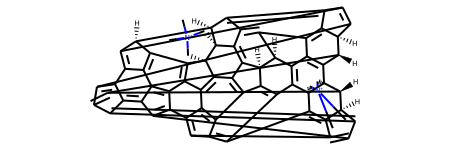

In [3]:
big_mol = Chem.MolFromSmiles(large_smi)
big_mol

In [4]:
DiG = Reduce2GoF(big_mol)

/home/tox/chemicalgof_repositories/chemicalgof-030/chemicalgof/utils.py:62: RuntimeWarning: Could not assign modern CIP labels: 
Digraph generation failed: more than 100000nodes found.
  warnings.warn(


As you can notice, by using RDKit, molecules composed of a large number of atoms can't be processed to find all chiral centers by not employing Legacy implementation algorithm.

In [5]:
fragsmiles = CanonicalGoF2fragSMILES(DiG)
fragsmiles

'C.<1>C1[NH2+]CC23C4=C5C6=C7c8c9c%10c%11c%12c%13c%14c%15c%16c%17c%18c%19c%20c%21c%22c%23c%24c%25c%26c%27c(c(c8c8c%10c%13c(c%278)c8c%14c%17c(c%24c%22%18)c%268)C172)C%25C3C=%23C4C%21c1c5c2c3c(c1-%20)C(C%19%16)C1(C[NH2+]CC%12%151)C3=C%11C9C62|3S43S44R45R47R48S55S56R57R61S64R65S<1>.<59>(C.).<59>(C.).C'

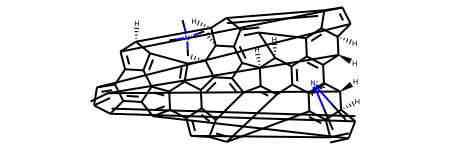

In [6]:
reassembled_mol = GoF2Mol(DiG)
reassembled_mol

In [7]:
reassembled_smiles = Chem.MolToSmiles(reassembled_mol)

assert reassembled_smiles == large_smi